

**Objective**
This study investigates the degree of synchrony between the Reserve Bank of Australia’s (RBA) *year-ended Consumer Price Index (CPI, %)* and the public salience of inflation on Reddit, the latter proxied by the quarterly mean vote score of inflation-related posts.

**Data and Methodology**

* **Datasets.** Quarterly CPI series released by the RBA and Reddit submissions whose titles or bodies contain inflation-relevant keywords.
* **Temporal alignment.** Both series are resampled to calendar quarter-end (“QE”). The CPI series is averaged within each quarter, while the Reddit metric is the mean vote score of posts in the same period.
* **Study window.** 2010 – 2025. The two quarterly series are concatenated and plotted on dual y-axes for visual comparison.

**Key Findings**

* **Strong co-movement.** The sharp surge in CPI during 2021-2022 is mirrored by an equally pronounced rise in Reddit vote averages, followed by a joint decline thereafter.
* **Minimal lag.** Turning points in the two series occur within the same quarter, indicating that online discussion intensity responds almost contemporaneously to official inflation prints.


**Conclusion**
Reddit attention to inflation, as captured by average post votes, exhibits a significant positive correlation with the RBA’s year-ended CPI and may serve as a timely barometer of public inflation sentiment.


In [1]:
"""
Team 71
Yifu Chen 1609437,  Kexing Ma 1697372, Jiejun Xie 1418316, Xinhe Liu 1477404, Anqi Liao 1578312
"""

import matplotlib.pyplot as plt
import nltk
import pandas as pd
from nltk.sentiment import SentimentIntensityAnalyzer
from typing import Literal


COL_NAME = {
    "vote": "score",
    "comment": "num_comments",
    "cpi": "Year-ended inflation",
}

In [2]:
from mkx.process_data.utils import POST_P, RBA_P, get_df


def tst2():
    nltk.download("vader_lexicon")


def datetime_to_str(series):
    return series.astype("string")


def str_to_datetime(series):
    return pd.to_datetime(series, errors="coerce", utc=True)


def clean_df(df, content: Literal["post", "rba"]):
    if content == "post":
        # 合并标题和正文当作文本；如果正文为空字符串也无妨
        df["text"] = df["title"].fillna("") + " " + df["selftext"].fillna("")
        # 把 UTC 时间戳转成 datetime，并扔掉未来日期或缺失值
        df["created_utc"] = str_to_datetime(df["created_utc"])
        df = df.dropna(subset=["created_utc"])
        df = df[df["created_utc"] <= pd.Timestamp.now(tz="UTC")]
        return df
    elif content == "rba":
        df["date"] = pd.to_datetime(df["date"], utc=True)
        return df
    raise NotImplementedError


def post_sentiment_scores(df):
    sia = SentimentIntensityAnalyzer()
    return df["text"].apply(sia.polarity_scores).apply(pd.Series)


def analyze_sentiment_scores(
        df, mode: Literal["valence", "arousal", "compound"]
) -> pd.Series:
    if mode == "valence":
        return df["pos"] - df["neg"]
    elif mode == "arousal":
        return df["compound"].abs()
    elif mode == "compound":
        return df["compound"]
    raise NotImplementedError


def statistic_by_season(
        df,
        date_column,
        on_column,
        rst_column_name,
        mode: Literal["size", "mean"],
        time_range_slice,
) -> pd.Series:
    rsp = df.set_index(date_column).resample("QE")

    if mode == "size":
        s = rsp.size()
    elif mode == "mean":
        s = rsp[on_column].mean()
    else:
        raise NotImplementedError
    return s.rename(rst_column_name).loc[time_range_slice]

In [ ]:
reddit = get_df(source="l", content="post")
reddit = clean_df(reddit, content="post")

print(reddit.head())
print(reddit.info())

# 按季度统计投票平均值
time_slice = slice("2010-05", "2025-05")
vote_mean = statistic_by_season(
    reddit,
    date_column="created_utc",
    on_column=COL_NAME["vote"],
    rst_column_name="vote_mean",
    mode="mean",
    time_range_slice=time_slice,
)

# noinspection PyTypeChecker
# scores: pd.DataFrame = post_sentiment_scores(reddit)

cpi = get_df(source="l", content="rba")
cpi = clean_df(cpi, "rba")
cpi_mean = statistic_by_season(
    cpi,
    date_column="date",
    on_column=COL_NAME["cpi"],
    rst_column_name="cpi_mean",
    mode="mean",
    time_range_slice=time_slice,
)

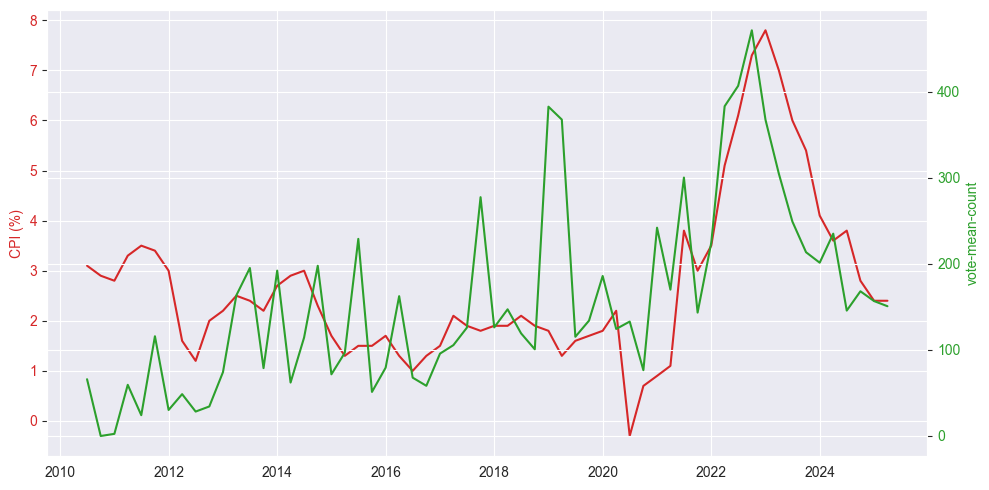

In [4]:
ts = pd.concat([cpi_mean, vote_mean], axis=1).fillna(0)

fig, ax1 = plt.subplots(figsize=(10, 5))
color1, color2, color3 = "tab:red", "tab:blue", "tab:green"

ax1.set_ylabel("CPI (%)", color=color1)
ax1.plot(ts.index, ts.iloc[:, 0], label="CPI", color=color1)
ax1.tick_params(axis="y", labelcolor=color1)

ax3 = ax1.twinx()
ax3.set_ylabel("vote-mean-count", color=color3)
ax3.plot(ts.index, ts.iloc[:, 1], label="vote-mean-count", color=color3)
ax3.tick_params(axis="y", labelcolor=color3)

fig.tight_layout()
plt.show()

In [8]:
ts.corr()

,cpi_mean,vote_mean
cpi_mean,1.000000,0.551011
vote_mean,0.551011,1.000000
